In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import matplotlib.dates as mdates

In [3]:
df=pd.read_csv('data/full_grouped.csv')
display(
    df.info,
    print(),
    df.columns,
     print(),
    df.head(),
     print(),
    df.shape,
     print(),
    df.dtypes
)

<bound method DataFrame.info of              Date      Country/Region  Confirmed  Deaths  Recovered  Active  \
0      2020-01-22         Afghanistan          0       0          0       0   
1      2020-01-22             Albania          0       0          0       0   
2      2020-01-22             Algeria          0       0          0       0   
3      2020-01-22             Andorra          0       0          0       0   
4      2020-01-22              Angola          0       0          0       0   
...           ...                 ...        ...     ...        ...     ...   
35151  2020-07-27  West Bank and Gaza      10621      78       3752    6791   
35152  2020-07-27      Western Sahara         10       1          8       1   
35153  2020-07-27               Yemen       1691     483        833     375   
35154  2020-07-27              Zambia       4552     140       2815    1597   
35155  2020-07-27            Zimbabwe       2704      36        542    2126   

       New cases  N

None

Index(['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'WHO Region'],
      dtype='object')

None

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


None

(35156, 10)

None

Date              object
Country/Region    object
Confirmed          int64
Deaths             int64
Recovered          int64
Active             int64
New cases          int64
New deaths         int64
New recovered      int64
WHO Region        object
dtype: object

In [4]:
df.isnull().sum
df.duplicated().sum

<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
35151    False
35152    False
35153    False
35154    False
35155    False
Length: 35156, dtype: bool>

In [5]:
df['Date']=pd.to_datetime(df['Date'])

In [6]:
df.dtypes

Date              datetime64[ns]
Country/Region            object
Confirmed                  int64
Deaths                     int64
Recovered                  int64
Active                     int64
New cases                  int64
New deaths                 int64
New recovered              int64
WHO Region                object
dtype: object

In [7]:
india=df[
    df['Country/Region']=='India'
    ].copy()
india.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
79,2020-01-22,India,0,0,0,0,0,0,0,South-East Asia
266,2020-01-23,India,0,0,0,0,0,0,0,South-East Asia
453,2020-01-24,India,0,0,0,0,0,0,0,South-East Asia
640,2020-01-25,India,0,0,0,0,0,0,0,South-East Asia
827,2020-01-26,India,0,0,0,0,0,0,0,South-East Asia


In [8]:
india=india.sort_values('Date').copy()
india.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
79,2020-01-22,India,0,0,0,0,0,0,0,South-East Asia
266,2020-01-23,India,0,0,0,0,0,0,0,South-East Asia
453,2020-01-24,India,0,0,0,0,0,0,0,South-East Asia
640,2020-01-25,India,0,0,0,0,0,0,0,South-East Asia
827,2020-01-26,India,0,0,0,0,0,0,0,South-East Asia


In [9]:
print("start date :",india['Date'].min)
print("\n end date :",india['Date'].max)

start date : <bound method Series.min of 79      2020-01-22
266     2020-01-23
453     2020-01-24
640     2020-01-25
827     2020-01-26
           ...    
34300   2020-07-23
34487   2020-07-24
34674   2020-07-25
34861   2020-07-26
35048   2020-07-27
Name: Date, Length: 188, dtype: datetime64[ns]>

 end date : <bound method Series.max of 79      2020-01-22
266     2020-01-23
453     2020-01-24
640     2020-01-25
827     2020-01-26
           ...    
34300   2020-07-23
34487   2020-07-24
34674   2020-07-25
34861   2020-07-26
35048   2020-07-27
Name: Date, Length: 188, dtype: datetime64[ns]>


In [10]:
india[['Date','Confirmed','Deaths','Recovered','Active','New cases','New deaths','New recovered']].head(15)

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered
79,2020-01-22,0,0,0,0,0,0,0
266,2020-01-23,0,0,0,0,0,0,0
453,2020-01-24,0,0,0,0,0,0,0
640,2020-01-25,0,0,0,0,0,0,0
827,2020-01-26,0,0,0,0,0,0,0
1014,2020-01-27,0,0,0,0,0,0,0
1201,2020-01-28,0,0,0,0,0,0,0
1388,2020-01-29,0,0,0,0,0,0,0
1575,2020-01-30,1,0,0,1,1,0,0
1762,2020-01-31,1,0,0,1,0,0,0


In [11]:
india['New cases'].max()

np.int64(49981)

In [12]:
india.loc[
    india['New cases'].idxmax(),['Date','New cases']
    ]

Date         2020-07-26 00:00:00
New cases                  49981
Name: 34861, dtype: object

In [13]:
india['rolling_cases']=(
    india['New cases'].rolling(7).mean()
)

In [14]:
india[['Date','New cases','rolling_cases']].head(30)

,Date,New cases,rolling_cases
79,2020-01-22,0,NaN
266,2020-01-23,0,NaN
453,2020-01-24,0,NaN
640,2020-01-25,0,NaN
827,2020-01-26,0,NaN
1014,2020-01-27,0,NaN
1201,2020-01-28,0,0.000000
1388,2020-01-29,0,0.000000
1575,2020-01-30,1,0.142857
1762,2020-01-31,0,0.142857


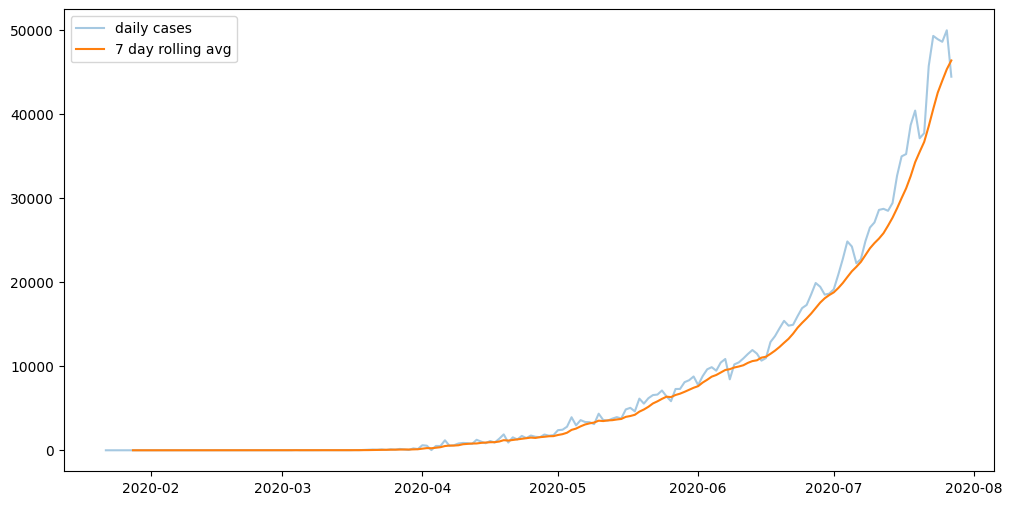

In [15]:
plt.figure(figsize=(12,6))
plt.plot(
    india['Date'],
    india['New cases'],
    label='daily cases',
    alpha=0.4
)
plt.plot(
    india['Date'],
    india['rolling_cases'],
    label='7 day rolling avg'
)
plt.savefig('visuals/india_covid_cases.png',dpi=300)
plt.legend()

COVID-19 confirmed cases in india

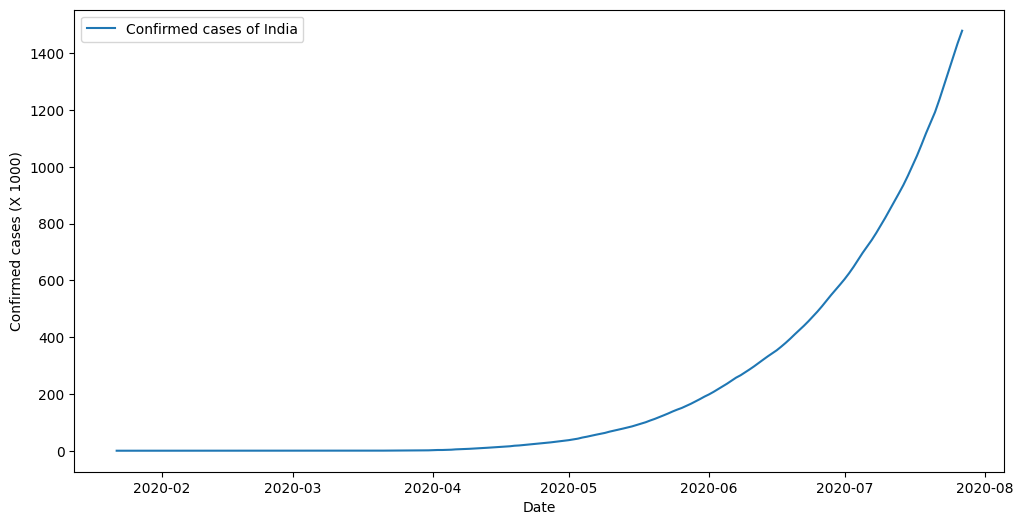

In [16]:
plt.figure(figsize=(12,6))

plt.plot(
    india['Date'],
    india['Confirmed']/1000,
    label='Confirmed cases of India'
    
)

plt.ylabel('Confirmed cases (X 1000)')

plt.xlabel("Date")

plt.legend()

plt.savefig('visuals/confirmed cases of india.png',dpi=300)

Deaths in india over time

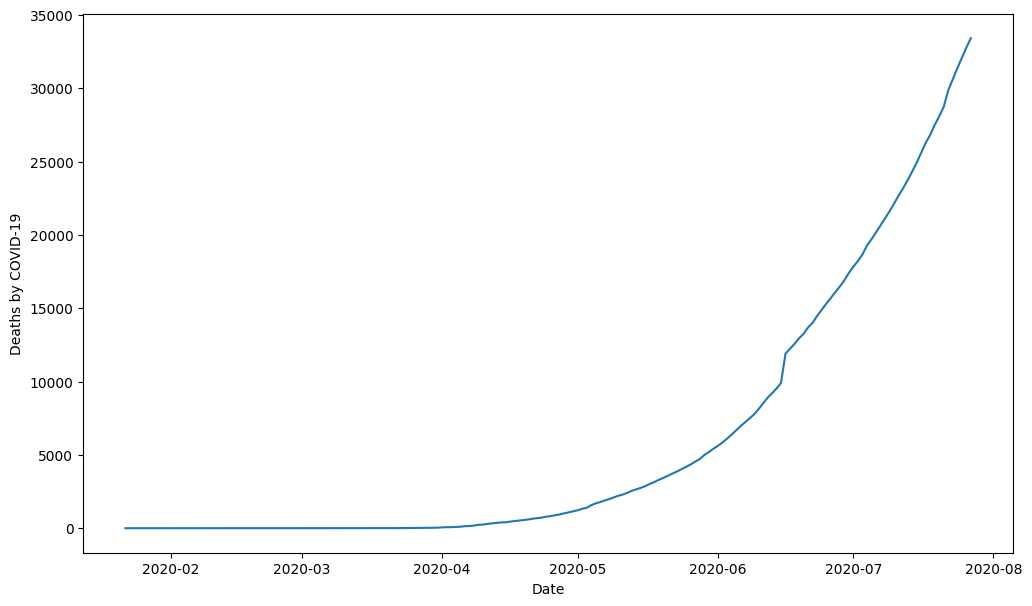

In [17]:
plt.figure(figsize=(12,7))

plt.plot(
    
    india['Date'],
    india['Deaths'],
    label='Deaths over time in india'

)

plt.xlabel('Date')
plt.ylabel('Deaths by COVID-19')
plt.savefig('visuals/deaths-over-time.png',dpi=300)

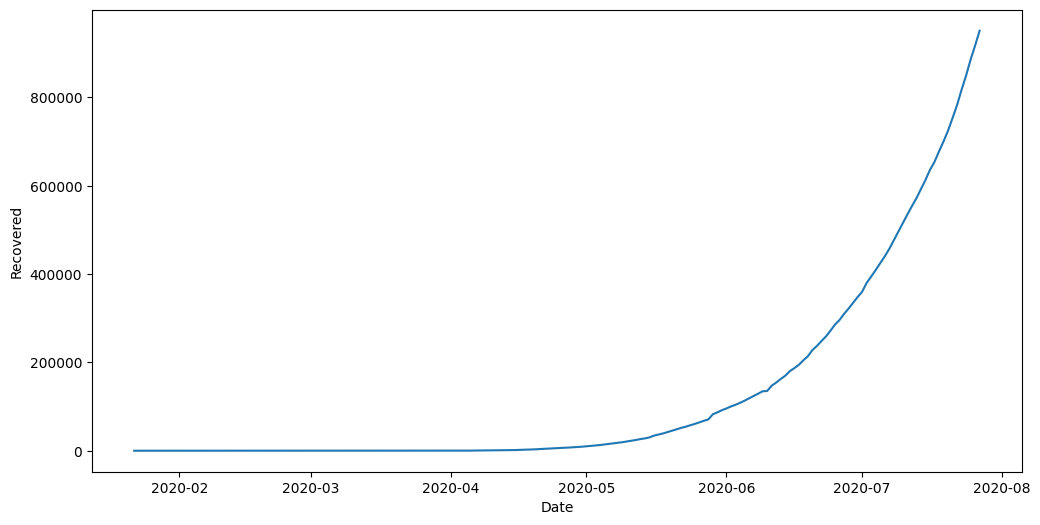

In [18]:
plt.figure(figsize=(12,6))

plt.plot(

    india['Date'],
    india['Recovered'],
    label='Recovered patients'

)

plt.xlabel('Date')

plt.ylabel('Recovered')

plt.savefig('visuals/Recovered.png',dpi=300)

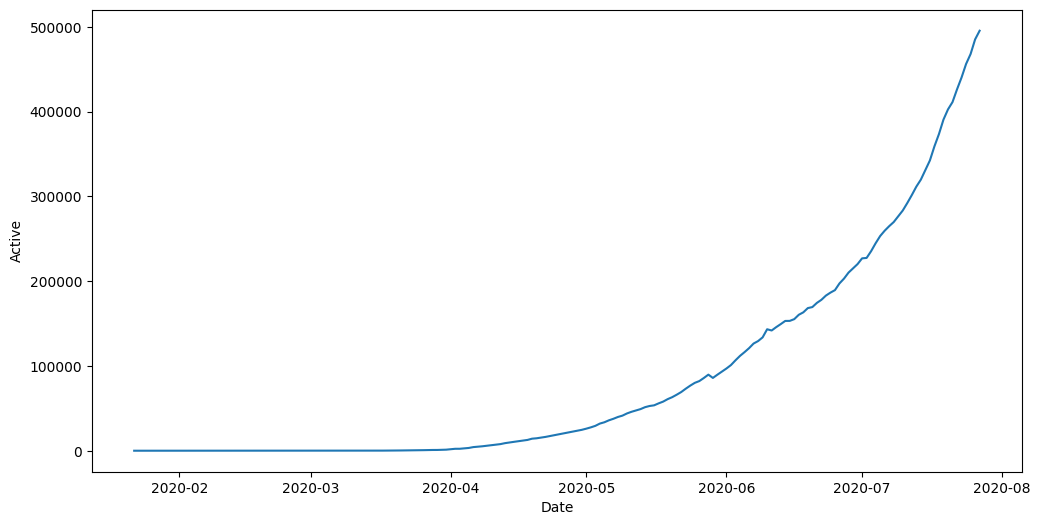

In [19]:
plt.figure(figsize=(12,6))

plt.plot(

    india['Date'],
    india['Active'],
    label='Active cases'

)

plt.xlabel('Date')

plt.ylabel('Active')

plt.savefig('visuals/Active-cases.png',dpi=300)

In [20]:
display(
    
    india.tail(1)[['Date','Confirmed','Deaths','Recovered','Active']]

)

print()

display(
    
    india.loc[india['Active'].idxmax(),
    ['Active','Date']]

)

print()

display(
    
    india.loc[india['New cases'].idxmax(),
    ['New cases','Date']]

)

print()

display(
    
    india.loc[india['New recovered'].idxmax(),
    ['New recovered','Date']]

)

print()

display(
    
    india.loc[india['New deaths'].idxmax(),
    ['New deaths','Date']]

)

,Date,Confirmed,Deaths,Recovered,Active
35048,2020-07-27,1480073,33408,951166,495499


Active                 495499
Date      2020-07-27 00:00:00
Name: 35048, dtype: object

New cases                  49981
Date         2020-07-26 00:00:00
Name: 34861, dtype: object

New recovered                  36141
Date             2020-07-25 00:00:00
Name: 34674, dtype: object

New deaths                   2003
Date          2020-06-16 00:00:00
Name: 27381, dtype: object

In [21]:
countries=["India","US","China"]

comparison=df[
    df['Country/Region'].isin(countries)
].copy()

display(
    comparison['Country/Region'].unique(),
    comparison.shape,
    comparison['Country/Region'].value_counts(),
    comparison=comparison.sort_values('Date').copy(),
    
)
comparison.head(10)


array(['China', 'India', 'US'], dtype=object)

(564, 10)

Country/Region
China    188
India    188
US       188
Name: count, dtype: int64

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
36,2020-01-22,China,548,17,28,503,0,0,0,Western Pacific
79,2020-01-22,India,0,0,0,0,0,0,0,South-East Asia
173,2020-01-22,US,1,0,0,1,0,0,0,Americas
223,2020-01-23,China,643,18,30,595,95,1,2,Western Pacific
266,2020-01-23,India,0,0,0,0,0,0,0,South-East Asia
360,2020-01-23,US,1,0,0,1,0,0,0,Americas
410,2020-01-24,China,920,26,36,858,277,8,6,Western Pacific
453,2020-01-24,India,0,0,0,0,0,0,0,South-East Asia
547,2020-01-24,US,2,0,0,2,1,0,0,Americas
597,2020-01-25,China,1406,42,39,1325,486,16,3,Western Pacific


In [22]:
country_trends=comparison.pivot_table(

    index='Date',
    columns='Country/Region',
    values='Confirmed'
)
country_trends.head(20)

Country/Region,China,India,US
Date,,,
2020-01-22,548.0,0.0,1.0
2020-01-23,643.0,0.0,1.0
2020-01-24,920.0,0.0,2.0
2020-01-25,1406.0,0.0,2.0
2020-01-26,2075.0,0.0,5.0
2020-01-27,2877.0,0.0,5.0
2020-01-28,5509.0,0.0,5.0
2020-01-29,6087.0,0.0,5.0
2020-01-30,8141.0,1.0,5.0


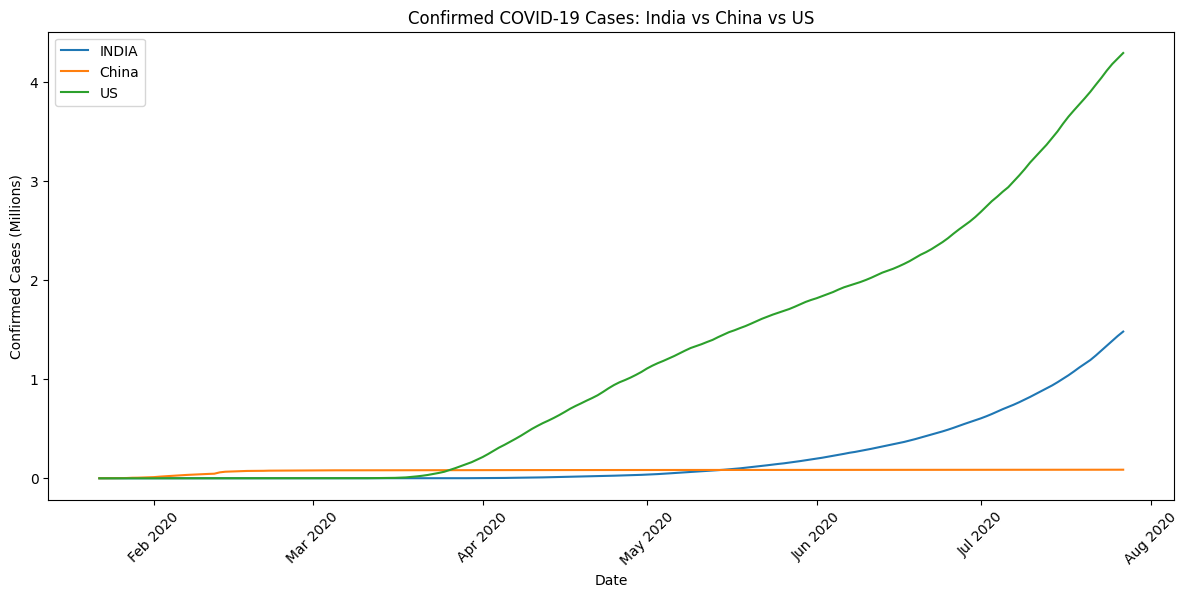

In [23]:
plt.figure(figsize=(12,6))

plt.plot(

    country_trends.index,
    country_trends['India']/1_000_000,
    label="INDIA"
)

plt.plot(

    country_trends.index,
    country_trends['China']/1_000_000,
    label="China"
)

plt.plot(

    country_trends.index,
    country_trends['US']/1_000_000,
    label="US"
)

plt.title("Confirmed COVID-19 Cases: India vs China vs US")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases (Millions)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)
plt.savefig(
    "visuals/country_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

In [25]:
comparison=comparison.sort_values('Date')

final_comparison=comparison.groupby('Country/Region').tail(1)

final_comparison[
    [
        "Country/Region",
        "Date",
        "Confirmed",
        "Deaths",
        "Recovered",
        "Active"
    ]
]


,Country/Region,Date,Confirmed,Deaths,Recovered,Active
35005,China,2020-07-27,86783,4656,78869,3258
35048,India,2020-07-27,1480073,33408,951166,495499
35142,US,2020-07-27,4290259,148011,1325804,2816444


In [28]:
confirmed_comparison=final_comparison[['Country/Region','Confirmed']].copy()
confirmed_comparison

,Country/Region,Confirmed
35005,China,86783
35048,India,1480073
35142,US,4290259


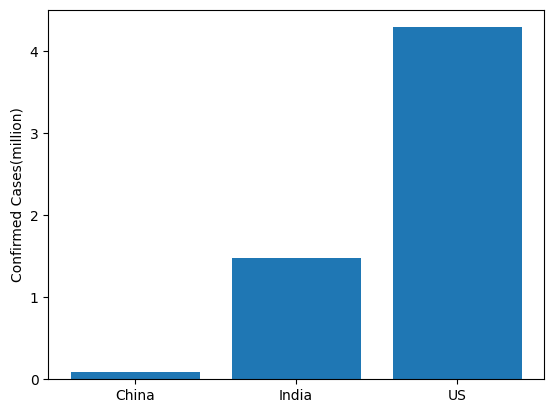

In [34]:
plt.bar(
    confirmed_comparison['Country/Region'],
        confirmed_comparison['Confirmed']/1_000_000

        )
plt.ylabel('Confirmed Cases(million)')

plt.savefig('visuals/comparison_bar_chart.png',dpi=300)

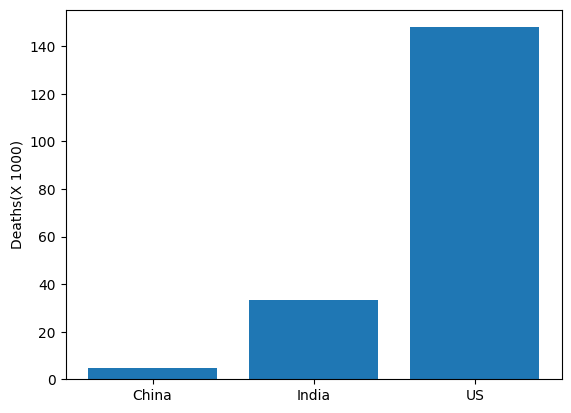

In [38]:
death_comparison=final_comparison[['Country/Region','Deaths']].copy()
death_comparison

plt.bar(
    death_comparison['Country/Region'],
        death_comparison['Deaths']/1_000

        )
plt.ylabel('Deaths(X 1000)')

plt.savefig('visuals/deaths_comparison_bar_chart.png',dpi=300)